# Agri-Detect: Improved Tomato Disease Classification

**Objective:** To build and document an efficient tomato disease classification model with a high accuracy, while explaining each step of the process in a clear and concise manner.

### 1. Environment Setup and Dependencies

This section imports the necessary libraries for data manipulation, visualization, and model building. We'll be using TensorFlow and Keras for the deep learning model.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow Version:', tf.__version__)

TensorFlow Version: 2.19.0


### 2. Exploratory Data Analysis (EDA)

Before we build the model, it's crucial to understand the dataset we're working with. In this EDA, we will:

*   **Visualize the class distribution:** To see how many images we have for each tomato disease.
*   **Display sample images:** To get a visual sense of the data.

Found 14678 images belonging to 10 classes.
Found 3667 images belonging to 10 classes.


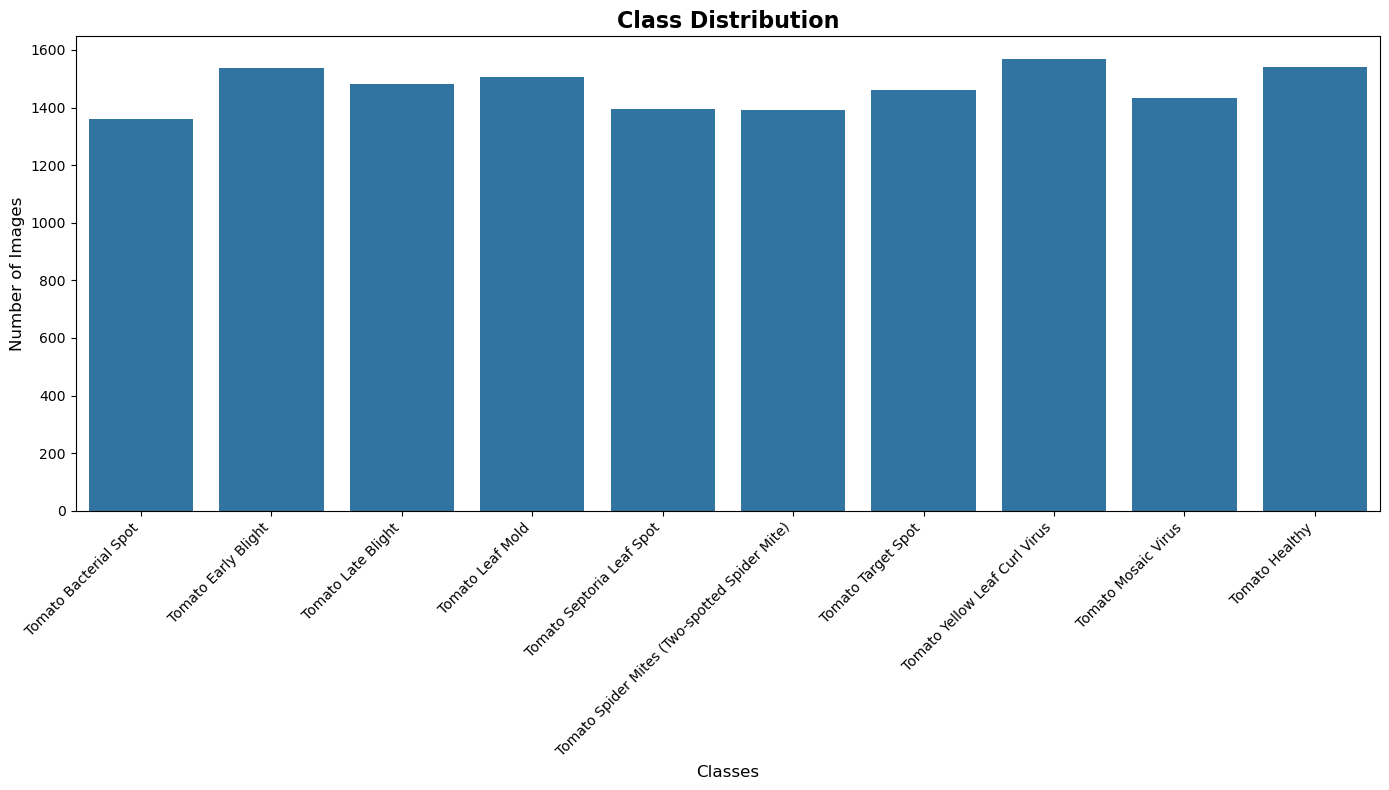

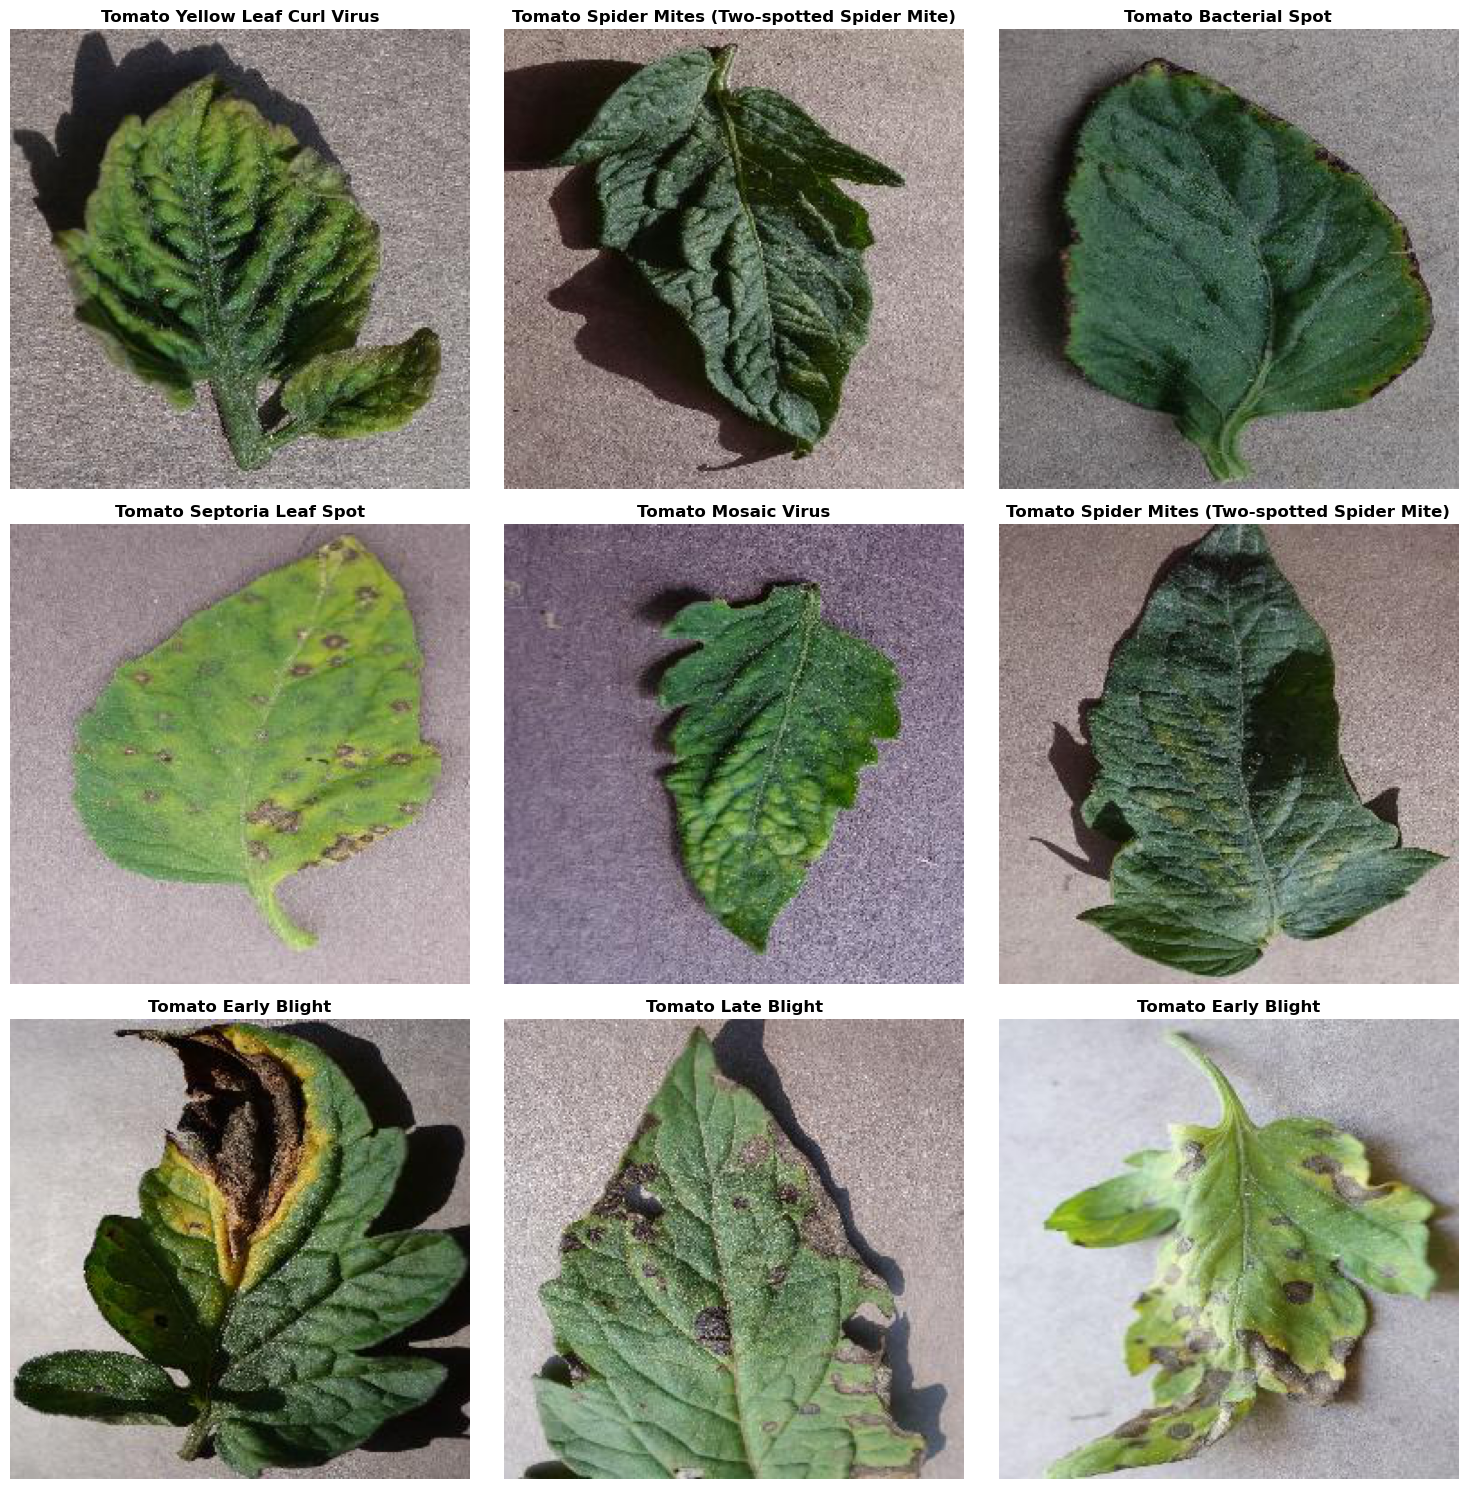

Class Index to Label Mapping:
0: Tomato___Bacterial_spot -> Tomato Bacterial Spot
1: Tomato___Early_blight -> Tomato Early Blight
2: Tomato___Late_blight -> Tomato Late Blight
3: Tomato___Leaf_Mold -> Tomato Leaf Mold
4: Tomato___Septoria_leaf_spot -> Tomato Septoria Leaf Spot
5: Tomato___Spider_mites Two-spotted_spider_mite -> Tomato Spider Mites (Two-spotted Spider Mite)
6: Tomato___Target_Spot -> Tomato Target Spot
7: Tomato___Tomato_Yellow_Leaf_Curl_Virus -> Tomato Yellow Leaf Curl Virus
8: Tomato___Tomato_mosaic_virus -> Tomato Mosaic Virus
9: Tomato___healthy -> Tomato Healthy


In [2]:
dataset_path = '..\Dataset\Tomato'

image_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2) # Using a generator for memory efficiency

train_generator = image_gen.flow_from_directory(
    dataset_path,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = image_gen.flow_from_directory(
    dataset_path,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# Define proper class labels mapping
class_label_mapping = {
    'Tomato___Bacterial_spot': 'Tomato Bacterial Spot',
    'Tomato___Early_blight': 'Tomato Early Blight',
    'Tomato___healthy': 'Tomato Healthy',
    'Tomato___Late_blight': 'Tomato Late Blight',
    'Tomato___Leaf_Mold': 'Tomato Leaf Mold',
    'Tomato___Septoria_leaf_spot': 'Tomato Septoria Leaf Spot',
    'Tomato___Spider_mites Two-spotted_spider_mite': 'Tomato Spider Mites (Two-spotted Spider Mite)',
    'Tomato___Target_Spot': 'Tomato Target Spot',
    'Tomato___Tomato_mosaic_virus': 'Tomato Mosaic Virus',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 'Tomato Yellow Leaf Curl Virus'
}

# Get class names and convert to proper labels
original_class_names = list(train_generator.class_indices.keys())
class_names = [class_label_mapping.get(name, name) for name in original_class_names]

# Class Distribution
class_counts = pd.Series(train_generator.classes).value_counts()

plt.figure(figsize=(14, 8))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
# Use proper class names for x-axis labels
plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Sample Images
x_batch, y_batch = next(train_generator)

plt.figure(figsize=(15, 15))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i])
    # Use proper class names for titles
    class_index = np.argmax(y_batch[i])
    plt.title(class_names[class_index], fontsize=12, fontweight='bold')
    plt.axis('off')
plt.tight_layout()
plt.show()

# Print class mapping for reference
print("Class Index to Label Mapping:")
for i, (original, formatted) in enumerate(zip(original_class_names, class_names)):
    print(f"{i}: {original} -> {formatted}")

### 3. Data Augmentation

Data augmentation is a technique to artificially increase the size of our training dataset by creating modified versions of the images. This helps to make our model more robust and prevent overfitting.

We will apply the following augmentations:

*   **Rotation:** Randomly rotate images.
*   **Width and Height Shift:** Randomly shift images horizontally and vertically.
*   **Shear:** Shear the image.
*   **Zoom:** Randomly zoom into images.
*   **Horizontal Flip:** Flip images horizontally.

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator_augmented = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator_augmented = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 14678 images belonging to 10 classes.
Found 3667 images belonging to 10 classes.


### 3.1. Visualizing Data Augmentation

To better understand the effects of our augmentation, let's visualize a few images from the training set after they've been transformed. This helps confirm that our `ImageDataGenerator` is working as expected and gives us a feel for the variety of data the model will be trained on.

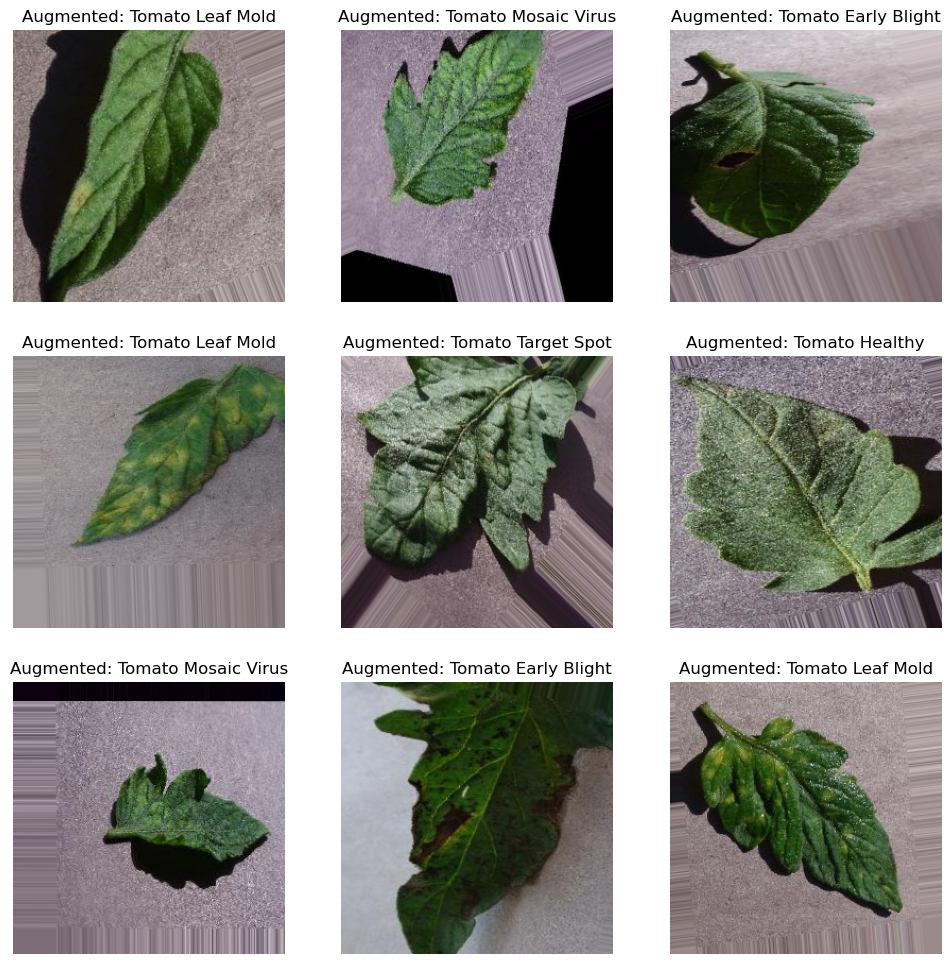

In [4]:
# Get a batch of augmented images and labels
augmented_images, augmented_labels = next(train_generator_augmented)

# Plot the augmented images
plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[i])
    plt.title(f"Augmented: {class_names[np.argmax(augmented_labels[i])]}")
    plt.axis('off')
plt.show()

### 4. Model Architecture: Baseline CNN

We will start with a simple Convolutional Neural Network (CNN) as our baseline model. The architecture consists of several convolutional and pooling layers, followed by dense layers for classification.

*   **Convolutional Layers (Conv2D):** These layers apply filters to the image to extract features like edges, corners, and textures.
*   **Max Pooling Layers (MaxPooling2D):** These layers down-sample the feature maps, reducing the spatial dimensions and making the model more efficient.
*   **Batch Normalization:** This technique is used to normalize the output of the previous layers, which helps to stabilize and accelerate the training process.
*   **Dropout:** This is a regularization technique where randomly selected neurons are ignored during training. This prevents the model from becoming too reliant on any single neuron and helps to prevent overfitting.
*   **Flatten:** This layer converts the 2D feature maps into a 1D vector, which can then be fed into the dense layers.
*   **Dense Layers:** These are fully connected layers that perform the final classification.

In [5]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    Flatten(),
    
    Dense(512, activation='relu'),
    Dropout(0.5),
    
    Dense(10, activation='softmax') # 10 classes for tomato diseases
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\mbuto\.conda\envs\heart\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    58,982,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,082,186 (225.38 MB)

 Trainable params: 59,081,738 (225.38 MB)

 Non-trainable params: 448 (1.75 KB)

### 5. Callbacks for Efficient Training

Callbacks are functions that can be applied at certain stages of the training process. We will use the following callbacks:

*   **ModelCheckpoint:** This callback saves the model after every epoch, but only if the validation accuracy has improved. This ensures that we always have the best version of the model saved.
*   **EarlyStopping:** This callback stops the training process if the validation loss does not improve for a certain number of epochs (defined by the `patience` parameter). This helps to prevent overfitting and saves computational resources.
*   **ReduceLROnPlateau:** This callback reduces the learning rate if the validation loss plateaus. This can help the model to escape local minima and find a better solution.

In [6]:
checkpoint = ModelCheckpoint('tomato_disease_model.h5', save_best_only=True, monitor='val_accuracy', mode='max', verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001, verbose=1)

### 6. Model Training

Now we will train the model using the augmented data. We will also use the validation set to monitor the model's performance on unseen data.

In [ ]:
history = model.fit(
    train_generator_augmented,
    epochs=7, # Increased epochs for better convergence
    validation_data=validation_generator_augmented,
    callbacks=[checkpoint, early_stopping, reduce_lr]
)

c:\Users\mbuto\.conda\envs\heart\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - accuracy: 0.3124 - loss: 15.3396 
Epoch 1: val_accuracy improved from -inf to 0.18926, saving model to tomato_disease_model.h5


459/459 ━━━━━━━━━━━━━━━━━━━━ 10235s 22s/step - accuracy: 0.3123 - loss: 15.3209 - val_accuracy: 0.1893 - val_loss: 13.0078 - learning_rate: 0.0010
Epoch 2/25
459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3361 - loss: 2.1803
Epoch 2: val_accuracy improved from 0.18926 to 0.41560, saving model to tomato_disease_model.h5


459/459 ━━━━━━━━━━━━━━━━━━━━ 1181s 3s/step - accuracy: 0.3361 - loss: 2.1800 - val_accuracy: 0.4156 - val_loss: 1.8611 - learning_rate: 0.0010
Epoch 3/25
459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3827 - loss: 1.8327
Epoch 3: val_accuracy did not improve from 0.41560
459/459 ━━━━━━━━━━━━━━━━━━━━ 961s 2s/step - accuracy: 0.3827 - loss: 1.8327 - val_accuracy: 0.3403 - val_loss: 2.2634 - learning_rate: 0.0010
Epoch 4/25
459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4098 - loss: 1.6982
Epoch 4: val_accuracy did not improve from 0.41560
459/459 ━━━━━━━━━━━━━━━━━━━━ 835s 2s/step - accuracy: 0.4098 - loss: 1.6981 - val_accuracy: 0.3968 - val_loss: 2.2362 - learning_rate: 0.0010
Epoch 5/25
459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4667 - loss: 1.5443
Epoch 5: val_accuracy improved from 0.41560 to 0.57377, saving model to tomato_disease_model.h5


459/459 ━━━━━━━━━━━━━━━━━━━━ 852s 2s/step - accuracy: 0.4667 - loss: 1.5442 - val_accuracy: 0.5738 - val_loss: 1.3459 - learning_rate: 0.0010
Epoch 6/25
459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4862 - loss: 1.4902
Epoch 6: val_accuracy did not improve from 0.57377
459/459 ━━━━━━━━━━━━━━━━━━━━ 830s 2s/step - accuracy: 0.4862 - loss: 1.4902 - val_accuracy: 0.3245 - val_loss: 4.9889 - learning_rate: 0.0010
Epoch 7/25
459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4665 - loss: 1.5776

### 7. Model Evaluation and Visualization

After training, we need to evaluate the model's performance. We will:

*   **Plot the training history:** To visualize the model's accuracy and loss over time.
*   **Generate a classification report:** To see the precision, recall, and F1-score for each class.
*   **Create a confusion matrix:** To visualize the model's performance on the test set and see which classes are being confused with each other.

In [1]:
# Plot training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

# Classification Report and Confusion Matrix
Y_pred = model.predict(validation_generator_augmented)
y_pred = np.argmax(Y_pred, axis=1)

print('Classification Report')
print(classification_report(validation_generator_augmented.classes, y_pred, target_names=class_names))

print('Confusion Matrix')
cm = confusion_matrix(validation_generator_augmented.classes, y_pred)
plt.figure(figsize=(12, 12))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

NameError: name 'history' is not defined